#  Notebook 1: Logistic Regression Sentiment Analysis


## Cell 1: Imports & Setup

In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
import re
import os
import joblib

# Global chart style — clean, publication-ready
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.labelsize":   11,
    "axes.titlesize":   13,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "legend.fontsize":  10,
})

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.utils.class_weight import compute_class_weight
from wordcloud import WordCloud

for pkg in ["punkt", "stopwords", "wordnet", "omw-1.4", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

SEED = 42
np.random.seed(SEED)

# ── Shared helper: add italic caption below any figure ────────────────────────
def add_caption(fig, text):
    """Add a small italic figure caption below the chart area."""
    fig.text(0.5, -0.03, text,
             ha="center", fontsize=8.5, color="#555555",
             style="italic", wrap=True)

print("All imports successful.")

All imports successful.


## Cell 2: Load & Inspect Data

In [2]:
# ── Cell 2: Load & Inspect Data ───────────────────────────────────────────────
DATA_PATH = "cleaned_reviews_0-250.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print(f"\nMissing:\n{df.isnull().sum()}")
print(f"\nRating dist:\n{df['rating'].value_counts().sort_index()}")

Shape   : (519409, 8)
Columns : ['product_id', 'product_name', 'brand_name', 'price_usd', 'rating', 'review_text', 'skin_type', 'skin_tone']

Missing:
product_id      0
product_name    0
brand_name      0
price_usd       0
rating          0
review_text     0
skin_type       0
skin_tone       0
dtype: int64

Rating dist:
rating
1     28504
2     25591
3     39176
4     93871
5    332267
Name: count, dtype: int64


## Cell 3: Sentiment Labelling + Stratified 100k Sample

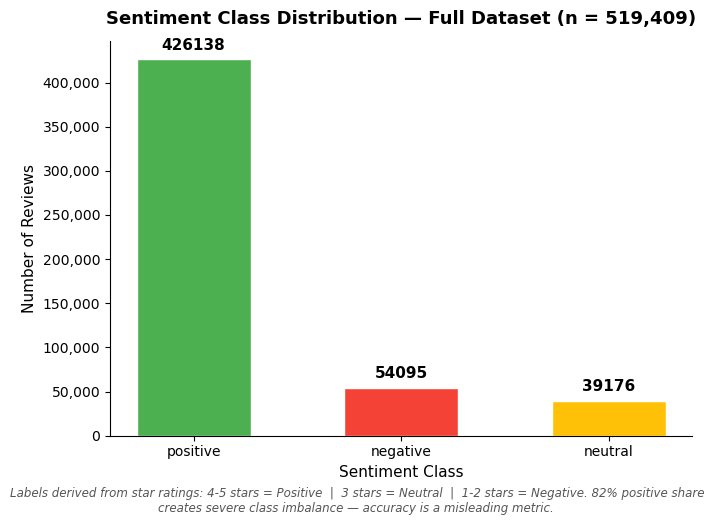


Class proportions:
sentiment
positive    0.820
negative    0.104
neutral     0.075
Name: proportion, dtype: float64

Stratified sample: 100,000 rows
sentiment
positive    82043
negative    10415
neutral      7542
Name: count, dtype: int64


In [3]:
# ── Cell 3: Sentiment Labelling + Class Distribution Chart ────────────────────
def assign_sentiment(rating):
    if rating >= 4:   return "positive"
    elif rating == 3: return "neutral"
    else:             return "negative"

df["sentiment"] = df["rating"].apply(assign_sentiment)

# ── Fig 1: Class Distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
counts = df["sentiment"].value_counts()
colors = {"positive": "#4CAF50", "neutral": "#FFC107", "negative": "#F44336"}
bars = ax.bar(counts.index, counts.values,
              color=[colors[s] for s in counts.index],
              edgecolor="white", width=0.55)
ax.bar_label(bars, fmt="%d", padding=5, fontsize=11, fontweight="bold")
ax.set_title(
    "Sentiment Class Distribution — Full Dataset (n = 519,409)",
    fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Sentiment Class")
ax.set_ylabel("Number of Reviews")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
add_caption(fig,
    "Labels derived from star ratings: 4-5 stars = Positive  |  "
    "3 stars = Neutral  |  1-2 stars = Negative. "
    "82% positive share creates severe class imbalance — "
    "accuracy is a misleading metric. ")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nClass proportions:\n{df['sentiment'].value_counts(normalize=True).round(3)}")

# ── Stratified 100k sample (AFTER sentiment column creation) ──────────────────
df, _ = train_test_split(df, train_size=100_000,
                          stratify=df["sentiment"], random_state=SEED)
df = df.reset_index(drop=True)
print(f"\nStratified sample: {len(df):,} rows")
print(df["sentiment"].value_counts())

## Cell 4: Text Preprocessing

In [4]:
# ── Cell 4: Text Preprocessing ────────────────────────────────────────────────
STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Lowercase -> remove URLs/HTML/special chars -> tokenise -> stopwords -> lemmatise."""
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    return " ".join([lemmatizer.lemmatize(t) for t in tokens
                     if t not in STOP_WORDS and len(t) > 2])

try:
    from tqdm import tqdm; tqdm.pandas()
    df["clean_text"] = df["review_text"].progress_apply(clean_text)
except ImportError:
    df["clean_text"] = df["review_text"].apply(clean_text)

df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
print(f"Preprocessing complete. Rows: {len(df):,}")
df.to_csv("preprocessed_100k.csv", index=False)
print("Saved preprocessed_100k.csv")

100%|████████████████████████████████| 100000/100000 [00:09<00:00, 10687.30it/s]


Preprocessing complete. Rows: 100,000
Saved preprocessed_100k.csv


## Cell 5: Price Tier Feature Engineering

In [5]:
# ── Cell 5: Price Tier Feature Engineering ────────────────────────────────────
df["price_tier"] = pd.qcut(
    df["price_usd"].fillna(df["price_usd"].median()),
    q=3, labels=["budget", "mid-range", "premium"])
print(f"\nPrice tier distribution:\n{df['price_tier'].value_counts()}")


Price tier distribution:
price_tier
budget       33929
premium      33166
mid-range    32905
Name: count, dtype: int64


## Cell 6: Train / Test Split (Stratified)

In [6]:
# ── Cell 6: Train / Test Split ────────────────────────────────────────────────
LABEL_MAP = {"negative": 0, "neutral": 1, "positive": 2}
df["label"] = df["sentiment"].map(LABEL_MAP)
X, y = df["clean_text"], df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 80,000  |  Test: 20,000


---
## TF-IDF Vectorisation
### Cell 7: Building the Feature Matrix

In [7]:
# ── Cell 7: TF-IDF Vectorisation ──────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2),
                         min_df=5, max_df=0.95, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"TF-IDF matrix (train): {X_train_tfidf.shape}")

TF-IDF matrix (train): (80000, 20000)


### Cell 8: Class Weights

In [8]:
# ── Cell 8: Class Weights ─────────────────────────────────────────────────────
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.array([0, 1, 2]), y=y_train)
cw_dict = dict(enumerate(class_weights))
print(f"Class weights: {cw_dict}")

Class weights: {0: 3.2005120819331094, 1: 4.419401171141311, 2: 0.40629348609968413}


### Cell 9: Logistic Regression Training

In [9]:
# ── Cell 9: Logistic Regression Training ──────────────────────────────────────
lr_model = LogisticRegression(
    max_iter=1000, C=1.0, solver="saga",
    class_weight=cw_dict, random_state=SEED, n_jobs=-1)
lr_model.fit(X_train_tfidf, y_train)
print("Logistic Regression trained.")

Logistic Regression trained.


### Cell 10: Model Evaluation


  Logistic Regression — Evaluation Report
              precision    recall  f1-score   support

    negative       0.30      0.93      0.46      2083
     neutral       0.33      0.23      0.27      1508
    positive       0.98      0.75      0.85     16409

    accuracy                           0.73     20000
   macro avg       0.54      0.64      0.52     20000
weighted avg       0.86      0.73      0.76     20000



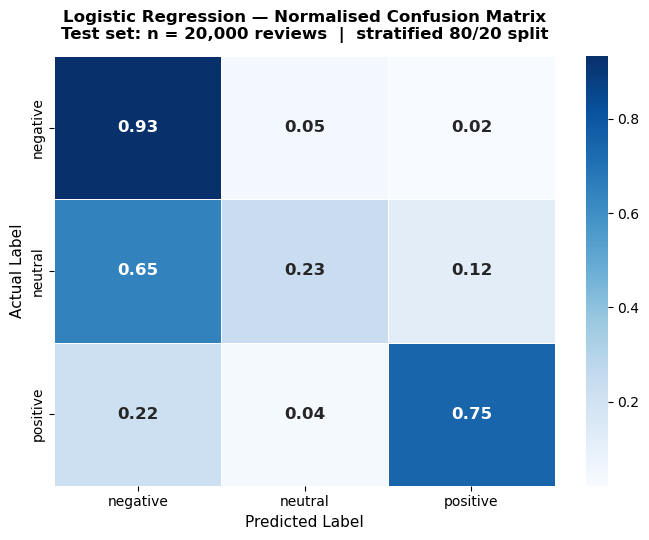

Macro ROC-AUC: 0.8794

Neg. Recall = 0.9323  (most commercially critical — identifies unhappy customers)


In [10]:
# ── Cell 10: Evaluation (with labelled confusion matrix) ──────────────────────
def evaluate_model(y_true, y_pred, y_prob, model_name="Model", cmap="Blues"):
    labels = ["negative", "neutral", "positive"]

    print(f"\n{'='*60}")
    print(f"  {model_name} — Evaluation Report")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=labels))

    # ── Confusion matrix
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                ax=ax, annot_kws={"size": 12, "weight": "bold"},
                linewidths=0.5)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("Actual Label", fontsize=11)
    ax.set_title(
        f"{model_name} — Normalised Confusion Matrix\n"
        f"Test set: n = {len(y_true):,} reviews  |  stratified 80/20 split",
        fontsize=12, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig(f"confusion_lr.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ROC-AUC
    y_bin = label_binarize(y_true, classes=[0, 1, 2])
    auc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    print(f"Macro ROC-AUC: {auc:.4f}")

    report = classification_report(y_true, y_pred,
                                   target_names=labels, output_dict=True)
    print(f"\nNeg. Recall = {report['negative']['recall']:.4f}  "
          f"(most commercially critical — identifies unhappy customers)")
    return auc

y_pred_lr = lr_model.predict(X_test_tfidf)
y_prob_lr = lr_model.predict_proba(X_test_tfidf)
auc_lr    = evaluate_model(y_test, y_pred_lr, y_prob_lr,
                           "Logistic Regression")

### Cell 11: 5-Fold Cross-Validation


5-Fold CV — F1 Macro    : 0.5710 +/- 0.0499
5-Fold CV — Recall Macro: 0.6609 +/- 0.0320


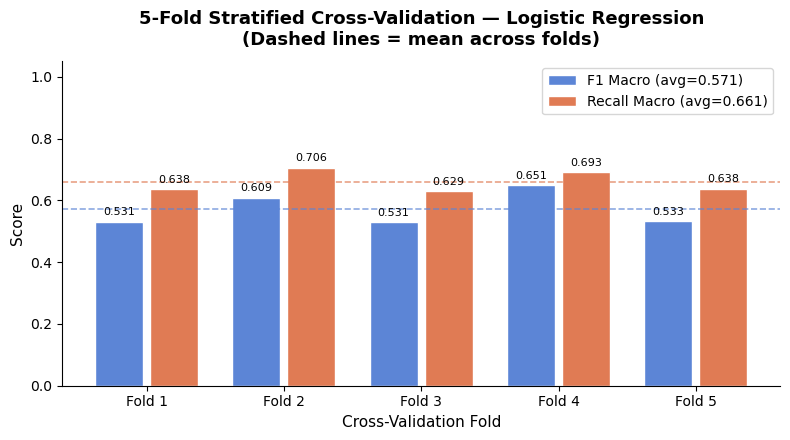

In [11]:
# ── Cell 11: Cross-Validation + Labelled Bar Chart ────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = cross_validate(
    lr_model, X_train_tfidf, y_train, cv=skf,
    scoring=["f1_macro", "recall_macro"], n_jobs=-1)

f1_mean  = cv_results["test_f1_macro"].mean()
f1_std   = cv_results["test_f1_macro"].std()
rec_mean = cv_results["test_recall_macro"].mean()
rec_std  = cv_results["test_recall_macro"].std()
print(f"\n5-Fold CV — F1 Macro    : {f1_mean:.4f} +/- {f1_std:.4f}")
print(f"5-Fold CV — Recall Macro: {rec_mean:.4f} +/- {rec_std:.4f}")

# ── Fig 6: CV Bar Chart ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
x  = np.arange(5)
b1 = ax.bar(x - 0.2, cv_results["test_f1_macro"],     0.35,
            label=f"F1 Macro (avg={f1_mean:.3f})",
            color="#5C85D6", edgecolor="white")
b2 = ax.bar(x + 0.2, cv_results["test_recall_macro"], 0.35,
            label=f"Recall Macro (avg={rec_mean:.3f})",
            color="#E07B54", edgecolor="white")
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=8)
ax.axhline(f1_mean,  color="#5C85D6", linestyle="--", linewidth=1.2, alpha=0.7)
ax.axhline(rec_mean, color="#E07B54", linestyle="--", linewidth=1.2, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Cross-Validation Fold")
ax.set_ylabel("Score")
ax.set_title(
    "5-Fold Stratified Cross-Validation — Logistic Regression\n"
    "(Dashed lines = mean across folds)",
    fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="upper right")
#add_caption(fig,
   # f"Fig 6. StratifiedKFold (n=5) preserves 82/10/8 class ratio in every fold. "
    #f"F1 Macro: {f1_mean:.4f} +/- {f1_std:.4f}  |  "
    #f"Recall Macro: {rec_mean:.4f} +/- {rec_std:.4f}. "
    #"Low fold variance confirms model stability. "
    #"Source: Sephora Reviews, Kaggle (train set, n = 80,000).")
plt.tight_layout()
plt.savefig("cv_scores_lr.png", dpi=150, bbox_inches="tight")
plt.show()

### Cell 12: Top TF-IDF Features per Class (Interpretability)

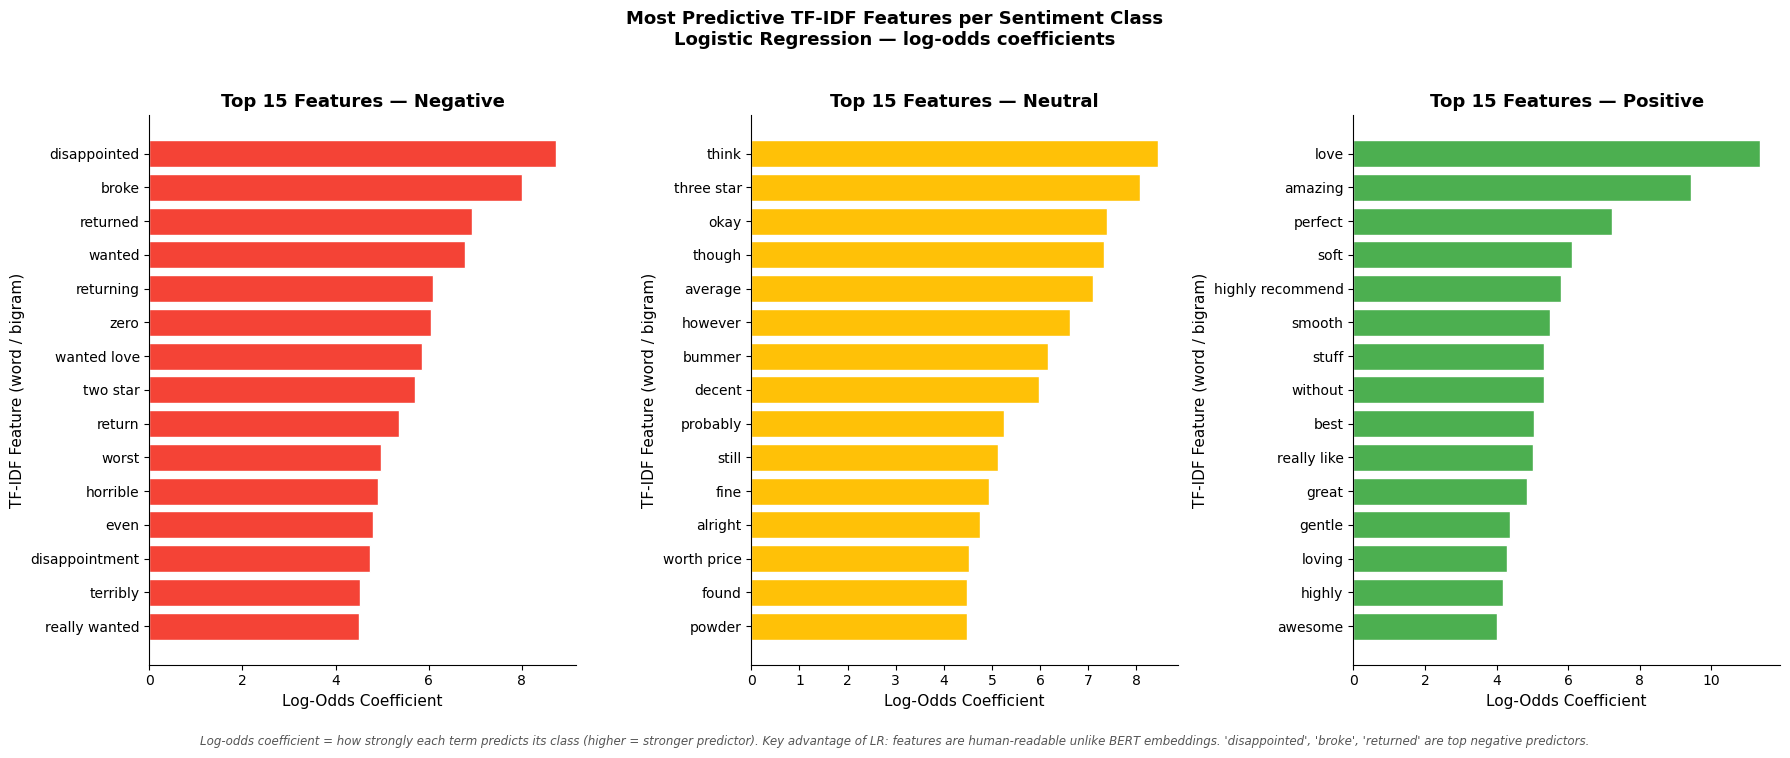

In [12]:
# ── Cell 12: Top TF-IDF Features per Class ────────────────────────────────────
feature_names_tfidf = np.array(tfidf.get_feature_names_out())
top_n = 15
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
class_labels = ["Negative", "Neutral", "Positive"]
colors_list  = ["#F44336", "#FFC107", "#4CAF50"]

for i, (label, color) in enumerate(zip(class_labels, colors_list)):
    coef      = lr_model.coef_[i]
    top_idx   = np.argsort(coef)[-top_n:]
    top_words = feature_names_tfidf[top_idx]
    top_vals  = coef[top_idx]
    axes[i].barh(top_words, top_vals, color=color, edgecolor="white")
    axes[i].set_title(f"Top {top_n} Features — {label}", fontweight="bold")
    axes[i].set_xlabel("Log-Odds Coefficient")
    axes[i].set_ylabel("TF-IDF Feature (word / bigram)")

fig.suptitle(
    "Most Predictive TF-IDF Features per Sentiment Class\n"
    "Logistic Regression — log-odds coefficients",
    fontsize=13, fontweight="bold", y=1.02)
add_caption(fig, "Log-odds coefficient = how strongly each term predicts its class "
   "(higher = stronger predictor). "
   "Key advantage of LR: features are human-readable unlike BERT embeddings. "
   "'disappointed', 'broke', 'returned' are top negative predictors.")
    #"Source: Sephora Reviews, Kaggle (TF-IDF 20k features, bigrams).")
plt.tight_layout()
plt.savefig("lr_top_features.png", dpi=150, bbox_inches="tight")
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# TOPIC MODELLING — LDA
# ══════════════════════════════════════════════════════════════════════════════

---
## Topic Modelling — LDA
### Cell 13: LDA on Negative Reviews

In [31]:
# ── Print top words with % contribution per topic ─────────────────────────────
def print_topic_percentages(model, feature_names, n_top=10, title=""):
    print(f"\n{'='*65}")
    print(f"  {title}")
    print(f"{'='*65}")
    for idx, topic in enumerate(model.components_):
        topic_total = topic.sum()
        top_idx     = topic.argsort()[:-n_top-1:-1]
        lbl = TOPIC_LABELS[idx] if idx < len(TOPIC_LABELS) else ""
        print(f"\nTopic {idx+1}: {lbl}")
        print(f"  {'Word':<20} {'Weight':>10}  {'% of topic':>10}")
        print(f"  {'-'*44}")
        for i in top_idx:
            word = feature_names[i]
            weight = topic[i]
            pct = (weight / topic_total) * 100
            print(f"  {word:<20} {weight:>10.1f}  {pct:>9.2f}%")

In [32]:
# ── Cell 13: LDA on Negative Reviews ─────────────────────────────────────────
N_TOPICS  = 7
neg_texts = df.loc[df["sentiment"] == "negative", "clean_text"]
print(f"Negative reviews for LDA: {len(neg_texts):,}")

cv_lda = CountVectorizer(max_features=20_000, ngram_range=(1, 2),
                          min_df=5, max_df=0.9)
dtm = cv_lda.fit_transform(neg_texts)

lda = LatentDirichletAllocation(
    n_components=N_TOPICS, max_iter=15,
    learning_method="online", random_state=SEED, n_jobs=-1)
lda.fit(dtm)
print_topic_percentages(lda, feature_names_lda,
                        title="LDA — Negative Reviews (% per topic)")
          
print(f"LDA trained. Perplexity: {lda.perplexity(dtm):.1f}")

feature_names_lda = cv_lda.get_feature_names_out()
print("\n-- TOP KEYWORDS PER TOPIC (Negative Reviews) --")
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names_lda[i] for i in topic.argsort()[:-15:-1]]
    print(f"Topic {idx+1}: {' | '.join(top_words)}")

Negative reviews for LDA: 10,415

  LDA — Negative Reviews (% per topic)

Topic 1: Lip & Makeup Removal
  Word                     Weight  % of topic
  --------------------------------------------
  lip                      1372.6       9.30%
  mask                      475.8       3.22%
  balm                      353.0       2.39%
  lip balm                  193.7       1.31%
  dry                       179.1       1.21%
  elephant                  157.7       1.07%
  drunk                     149.9       1.02%
  drunk elephant            148.0       1.00%
  night                     109.4       0.74%
  chapped                   107.5       0.73%

Topic 2: Acne & Time Effects
  Word                     Weight  % of topic
  --------------------------------------------
  eye                      1293.3       2.92%
  product                   913.2       2.06%
  difference                719.8       1.62%
  see                       656.7       1.48%
  money                     622.2   

### Cell 14: LDA Topic Visualisation

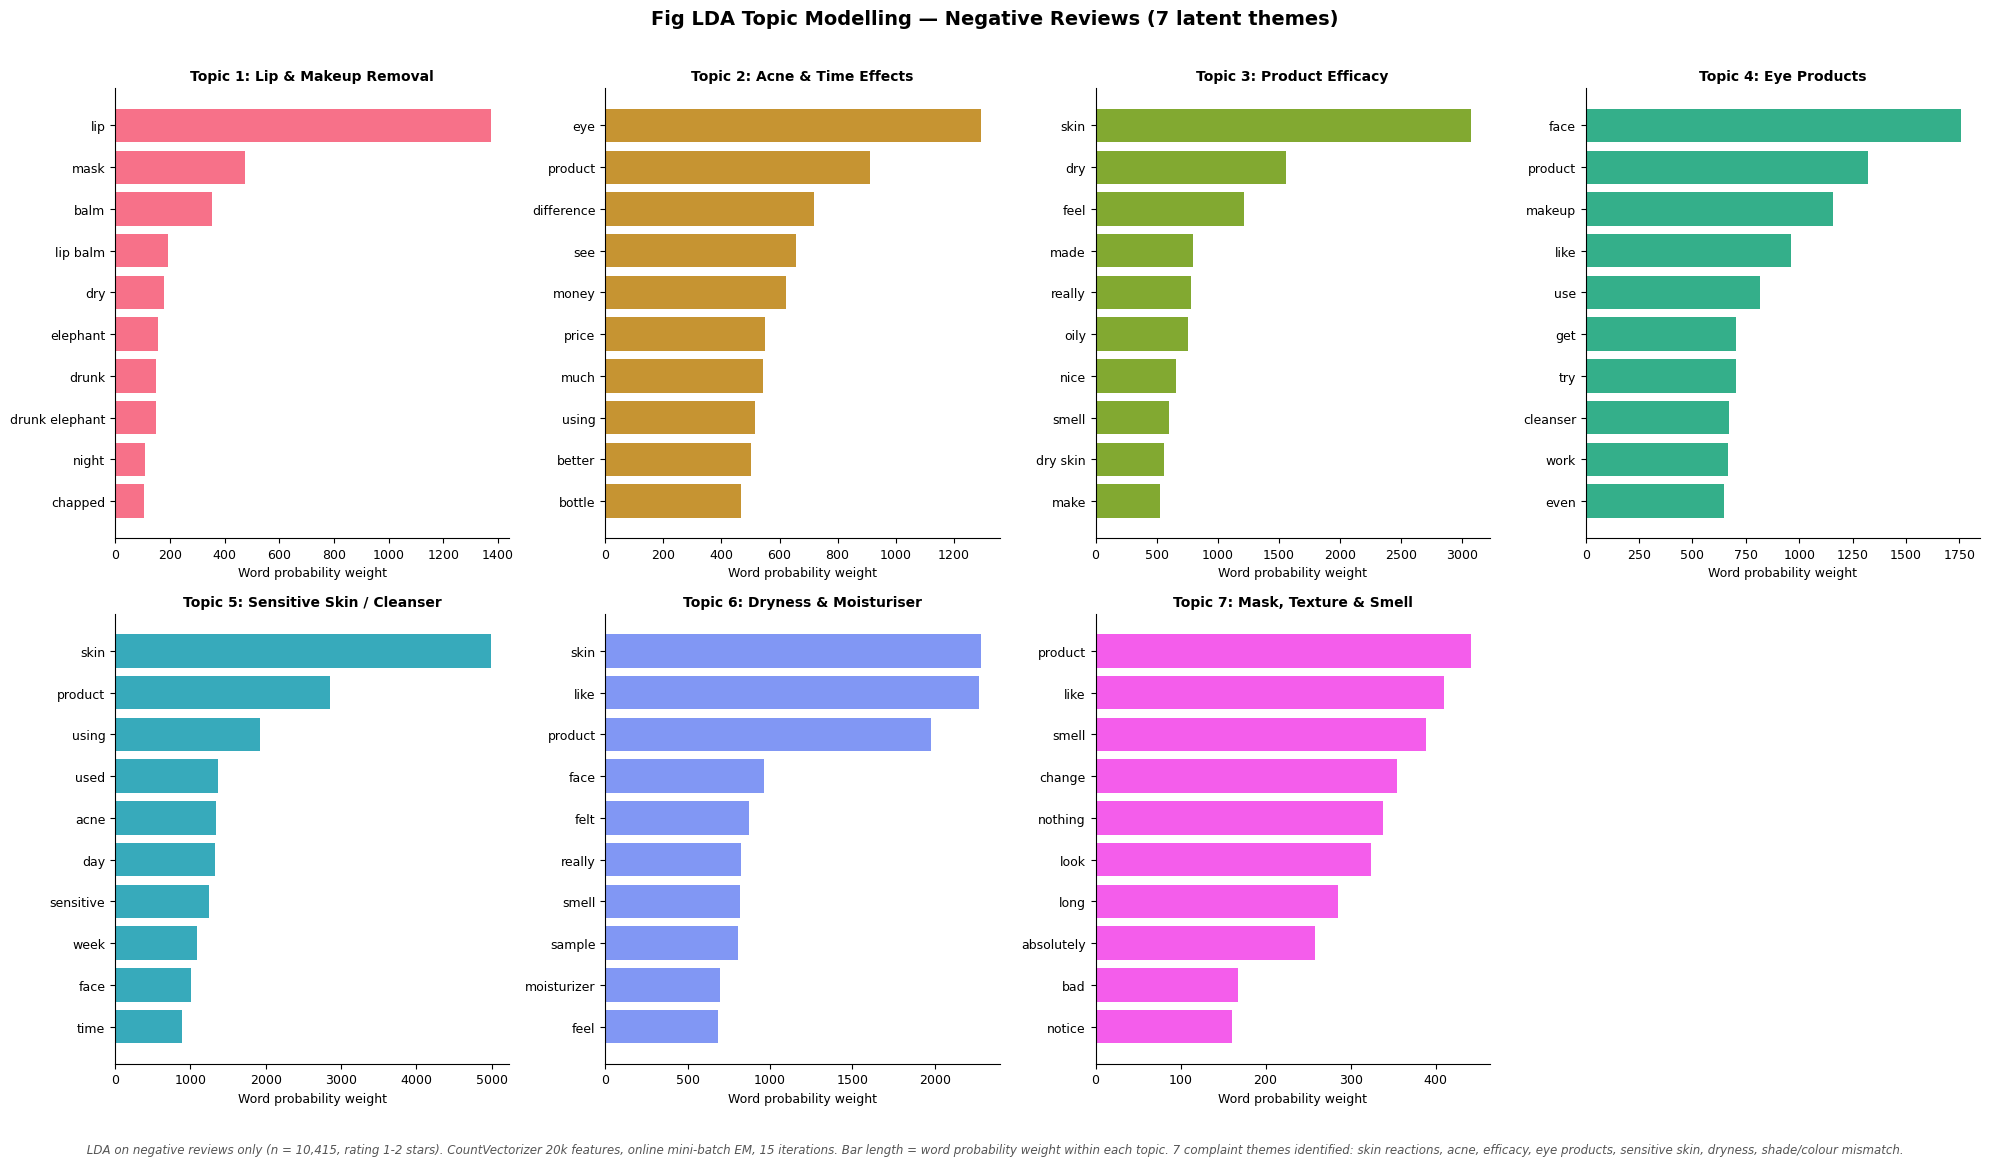

In [33]:
# ── Cell 14: LDA Topic Visualisation ─────────────────────────────────────────
TOPIC_LABELS = [
    "Lip & Makeup Removal",
    "Acne & Time Effects",
    "Product Efficacy",
    "Eye Products",
    "Sensitive Skin / Cleanser",
    "Dryness & Moisturiser",
    "Mask, Texture & Smell"
]

def plot_lda_topics(model, feature_names, n_top=10, n_topics=N_TOPICS,
                    suptitle="LDA Topics", filename="lda.png",
                    caption=""):
    fig, axes = plt.subplots(2, 4, figsize=(20, 11), sharex=False)
    axes   = axes.flatten()
    palette = sns.color_palette("husl", n_topics)

    for topic_idx, topic in enumerate(model.components_[:n_topics]):
        top_idx  = topic.argsort()[:-n_top-1:-1]
        top_feat = [feature_names[i] for i in top_idx]
        top_vals = topic[top_idx]
        lbl = TOPIC_LABELS[topic_idx] if topic_idx < len(TOPIC_LABELS) else ""
        axes[topic_idx].barh(top_feat[::-1], top_vals[::-1],
                              color=palette[topic_idx])
        axes[topic_idx].set_title(
            f"Topic {topic_idx+1}: {lbl}", fontweight="bold", fontsize=10)
        axes[topic_idx].set_xlabel("Word probability weight", fontsize=9)
        axes[topic_idx].tick_params(labelsize=9)

    for j in range(n_topics, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Fig {suptitle}",
                 fontsize=14, fontweight="bold", y=1.01)
    if caption:
        add_caption(fig, caption)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

plot_lda_topics(
    lda, feature_names_lda,
    suptitle="LDA Topic Modelling — Negative Reviews (7 latent themes)",
    filename="lda_topics_negative.png",
    caption=(
        f" LDA on negative reviews only (n = {len(neg_texts):,}, rating 1-2 stars). "
        "CountVectorizer 20k features, online mini-batch EM, 15 iterations. "
        "Bar length = word probability weight within each topic. "
        "7 complaint themes identified: skin reactions, acne, efficacy, eye products, "
        "sensitive skin, dryness, shade/colour mismatch. "))



### Cell 15: LDA on All Reviews


  LDA — All Reviews (% per topic)

Topic 1: Lip & Makeup Removal
  Word                     Weight  % of topic
  --------------------------------------------
  lip                     14255.5       4.40%
  makeup                  11113.8       3.43%
  balm                     6215.7       1.92%
  love                     4169.2       1.29%
  remove                   3434.6       1.06%
  cleansing                2969.6       0.92%
  like                     2717.4       0.84%
  use                      2677.6       0.83%
  smell                    2661.7       0.82%
  take                     2631.9       0.81%

Topic 2: Acne & Time Effects
  Word                     Weight  % of topic
  --------------------------------------------
  little                   9256.8       1.59%
  long                     8221.8       1.41%
  using                    7285.3       1.25%
  size                     6903.2       1.19%
  acne                     6710.4       1.15%
  time                     6

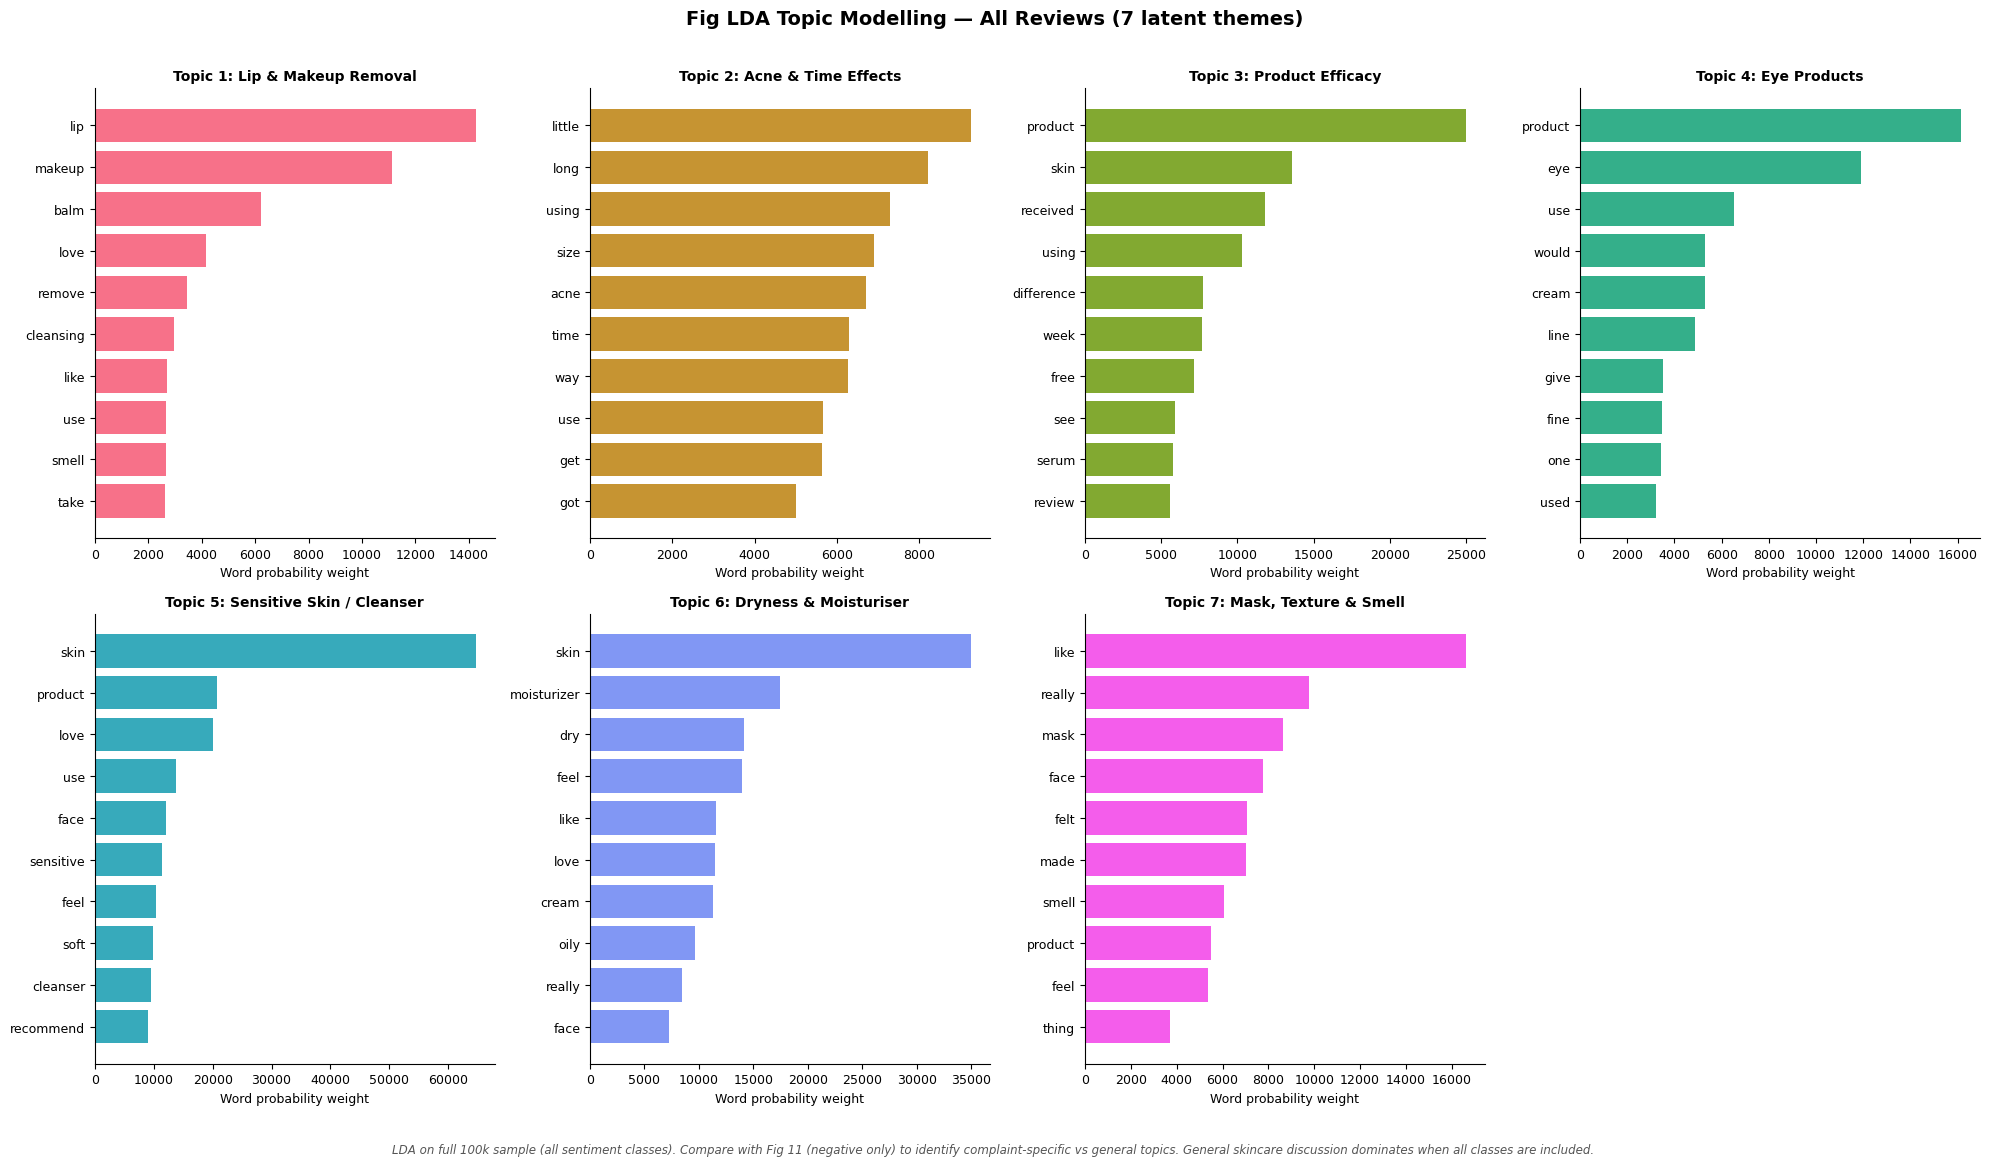

In [34]:
# ── Cell 15: LDA on All Reviews ───────────────────────────────────────────────
all_dtm = cv_lda.transform(df["clean_text"])
lda_all = LatentDirichletAllocation(
    n_components=N_TOPICS, max_iter=15,
    learning_method="online", random_state=SEED, n_jobs=-1)
lda_all.fit(all_dtm)
print_topic_percentages(lda_all, feature_names_lda,
                        title="LDA — All Reviews (% per topic)")

plot_lda_topics(
    lda_all, feature_names_lda,
    suptitle="LDA Topic Modelling — All Reviews (7 latent themes)",
    filename="lda_topics_all.png",
    caption=(
        f"LDA on full 100k sample (all sentiment classes). "
        "Compare with Fig 11 (negative only) to identify complaint-specific vs general topics. "
        "General skincare discussion dominates when all classes are included. "))


# ══════════════════════════════════════════════════════════════════════════════
# WORD CLOUDS & FREQUENCY VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════════

---
## Word Clouds & Frequency Visualisations
### Cell 16: Word Clouds

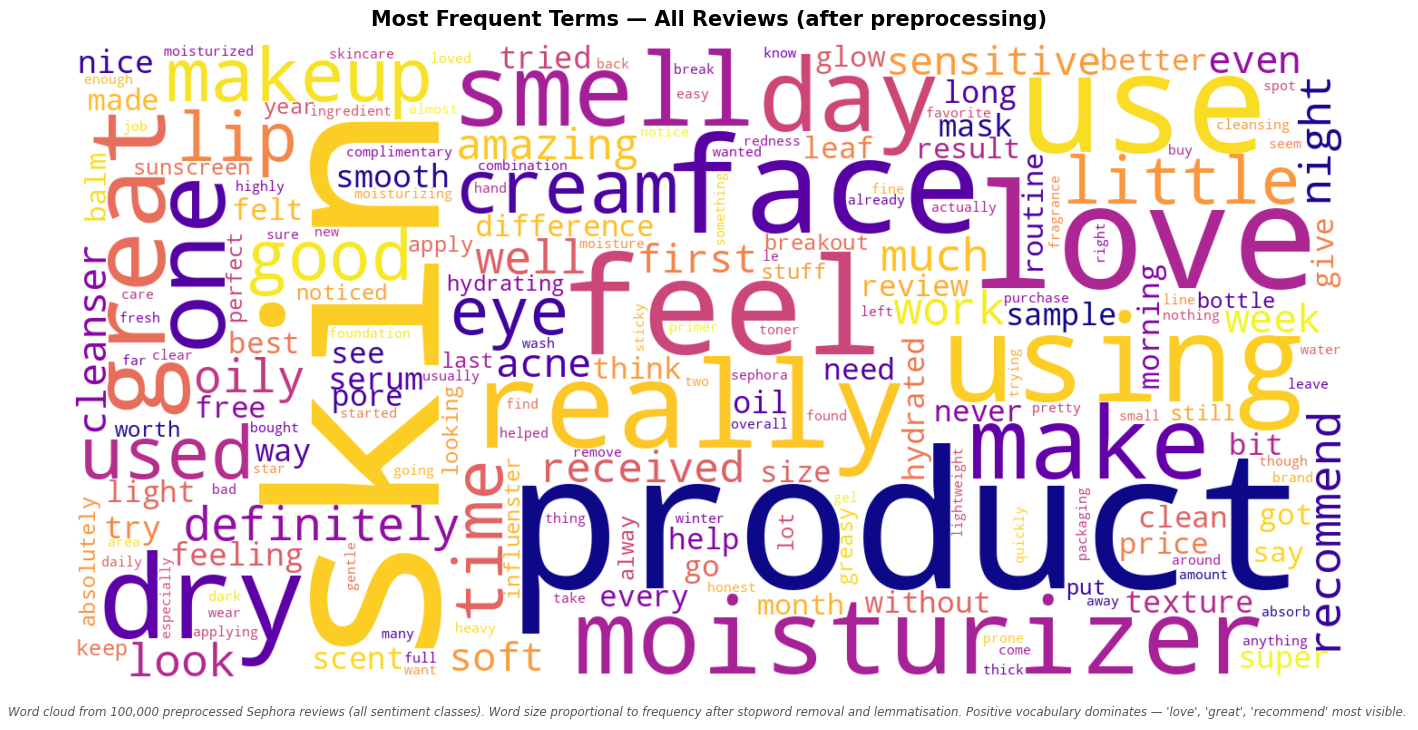

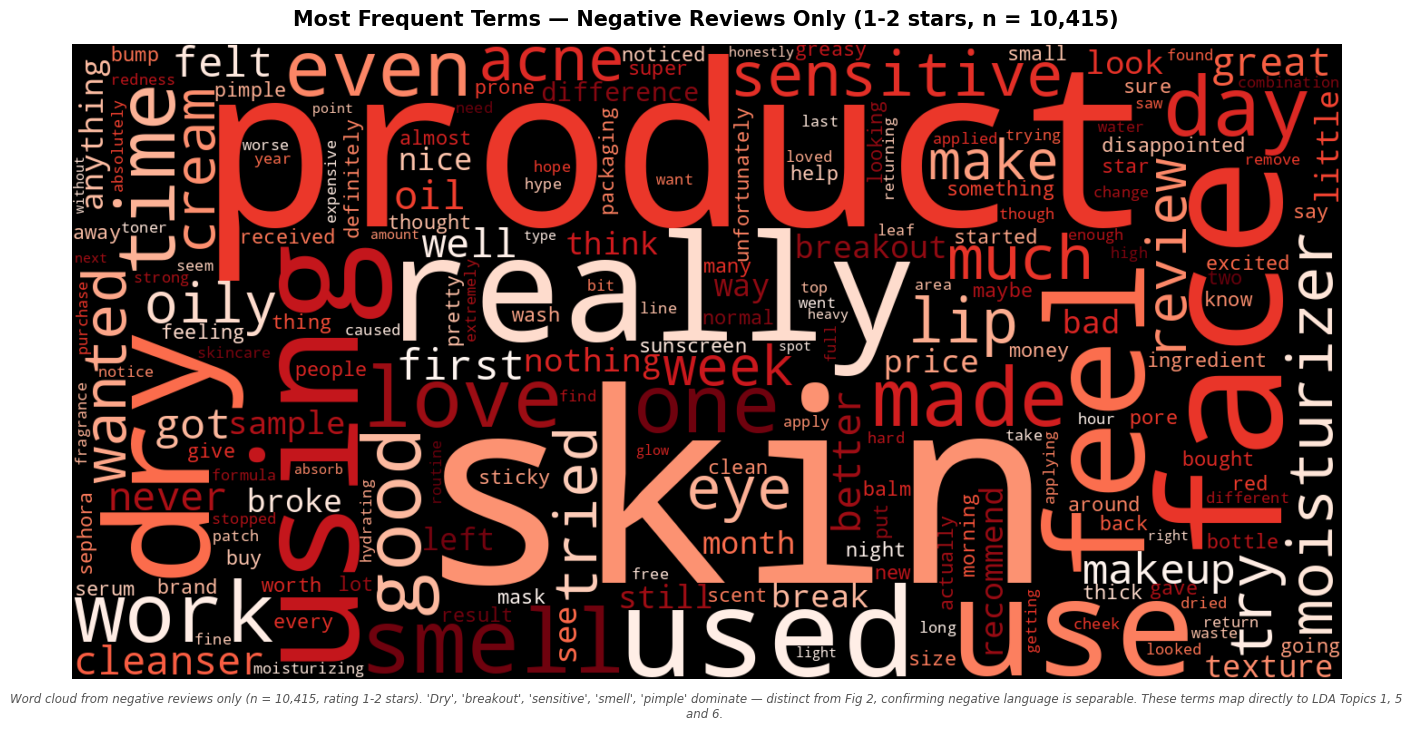

In [18]:
# ── Cell 16: Word Clouds ──────────────────────────────────────────────────────
def generate_wordcloud(text_series, title, filename, caption,
                       colormap="viridis", bg="white"):
    corpus = " ".join(text_series.dropna())
    wc = WordCloud(width=1400, height=700, background_color=bg,
                   colormap=colormap, max_words=200,
                   collocations=False).generate(corpus)
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{title}",
                 fontsize=15, fontweight="bold", pad=14)
    add_caption(fig, caption)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

generate_wordcloud(
    df["clean_text"],
    title="Most Frequent Terms — All Reviews (after preprocessing)",
    filename="wordcloud_all.png",
    caption=(
        "Word cloud from 100,000 preprocessed Sephora reviews (all sentiment classes). "
        "Word size proportional to frequency after stopword removal and lemmatisation. "
        "Positive vocabulary dominates — 'love', 'great', 'recommend' most visible. "),
    colormap="plasma")

n_neg = (df["sentiment"] == "negative").sum()
generate_wordcloud(
    df.loc[df["sentiment"] == "negative", "clean_text"],
    title=f"Most Frequent Terms — Negative Reviews Only (1-2 stars, n = {n_neg:,})",
    filename="wordcloud_negative.png",
    caption=(
        f"Word cloud from negative reviews only (n = {n_neg:,}, rating 1-2 stars). "
        "'Dry', 'breakout', 'sensitive', 'smell', 'pimple' dominate — "
        "distinct from Fig 2, confirming negative language is separable. "
        "These terms map directly to LDA Topics 1, 5 and 6. "),
    colormap="Reds", bg="black")

### Cell 17: Top Frequent Words Bar Chart

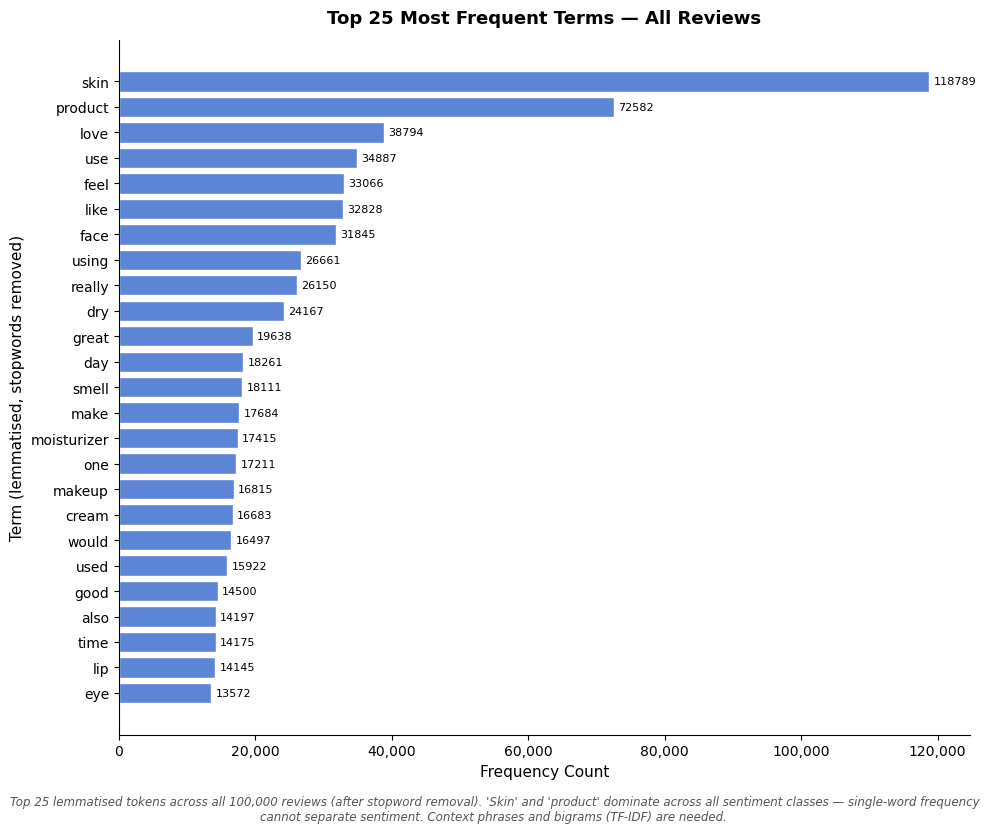

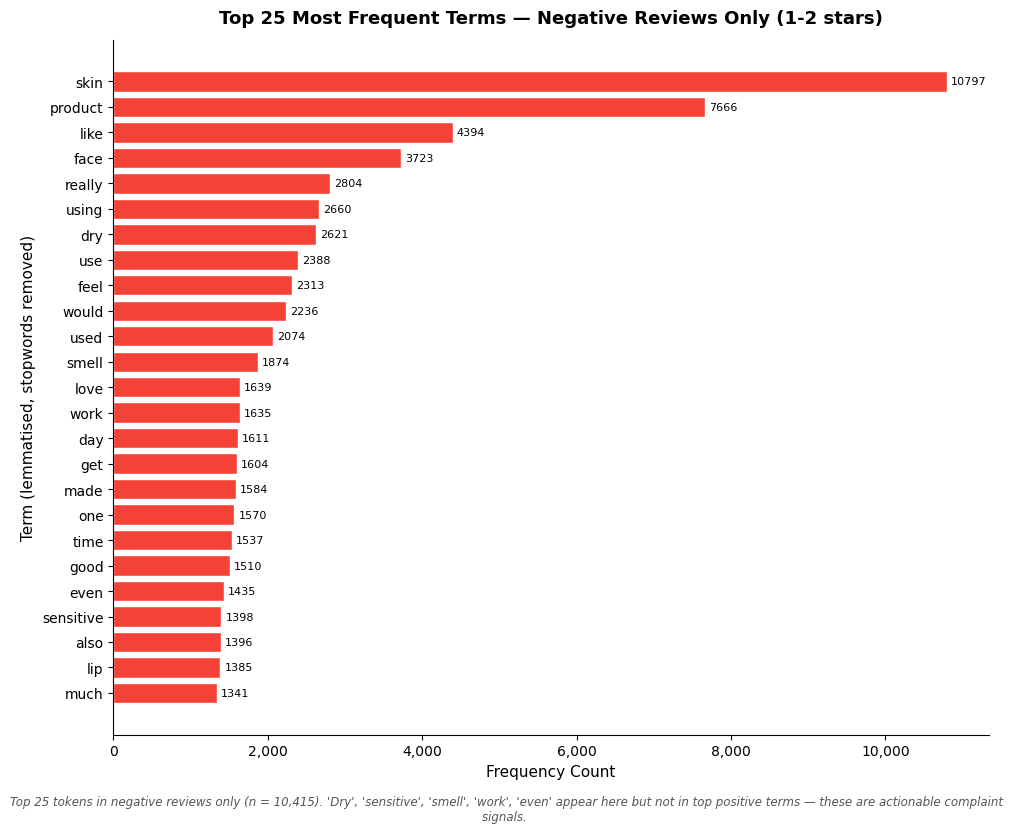

In [19]:
# ── Cell 17: Top Frequent Words Bar Charts ────────────────────────────────────
def top_words_barplot(text_series, title, filename, caption,
                      n=25, color="#5C85D6"):
    all_words = " ".join(text_series).split()
    freq = Counter(all_words).most_common(n)
    words, counts = zip(*freq)
    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(words[::-1], counts[::-1], color=color, edgecolor="white")
    ax.bar_label(bars, fmt="%d", padding=3, fontsize=8)
    ax.set_title(f"{title}",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Frequency Count")
    ax.set_ylabel("Term (lemmatised, stopwords removed)")
    ax.xaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
    add_caption(fig, caption)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()

top_words_barplot(
    df["clean_text"],
    title="Top 25 Most Frequent Terms — All Reviews",
    filename="top_words_all.png",
    caption=(
        f"Top 25 lemmatised tokens across all {len(df):,} reviews "
        "(after stopword removal). 'Skin' and 'product' dominate across all sentiment classes — "
        "single-word frequency cannot separate sentiment. "
        "Context phrases and bigrams (TF-IDF) are needed. "))

top_words_barplot(
    df.loc[df["sentiment"] == "negative", "clean_text"],
    title=f"Top 25 Most Frequent Terms — Negative Reviews Only (1-2 stars)",
    filename="top_words_negative.png",
    caption=(
        f"Top 25 tokens in negative reviews only (n = {n_neg:,}). "
        "'Dry', 'sensitive', 'smell', 'work', 'even' appear here but not in top positive terms — "
        "these are actionable complaint signals. "),
    color="#F44336")


# ══════════════════════════════════════════════════════════════════════════════
# SEGMENTATION ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════

---
## Segmentation Analysis
### Cell 18: Cross-Tabulation Helper

In [20]:
# ── Cell 18: Cross-Tabulation Helper ──────────────────────────────────────────
def plot_crosstab(dataframe, group_col, title, filename,
                  caption, figsize=(12, 5.5)):
    """Normalised stacked bar chart with full labels and caption."""
    col = dataframe[group_col].astype(str).replace("nan", "Unknown")
    ct  = pd.crosstab(col, dataframe["sentiment"],
                      normalize="index")[["negative", "neutral", "positive"]]

    fig, ax = plt.subplots(figsize=figsize)
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=["#F44336", "#FFC107", "#4CAF50"],
            edgecolor="white", width=0.65)
    ax.set_title(f"{title}",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(group_col.replace("_", " ").title(), fontsize=11)
    ax.set_ylabel("Proportion of Reviews", fontsize=11)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.legend(["Negative", "Neutral", "Positive"],
              loc="upper right", title="Sentiment", framealpha=0.9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
    add_caption(fig, caption)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    return ct

### Cell 19: Skin Type Segmentation

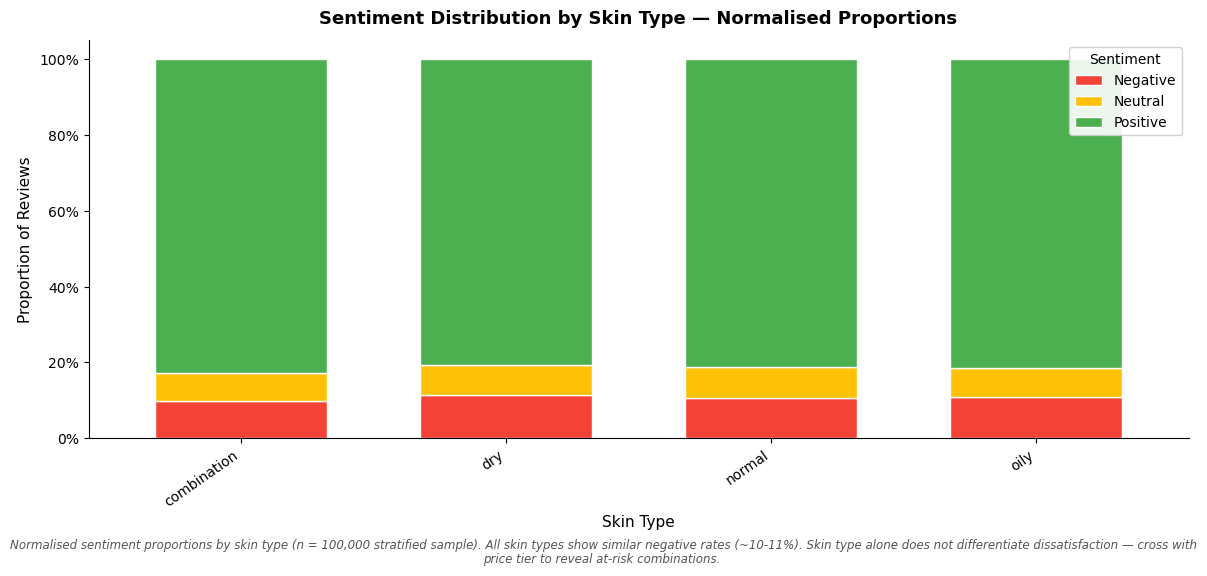

sentiment    negative  neutral  positive
skin_type                               
combination     0.099    0.074     0.827
dry             0.114    0.078     0.808
normal          0.107    0.080     0.813
oily            0.108    0.076     0.816


In [21]:
# ── Cell 19: Skin Type Segmentation ───────────────────────────────────────────
ct_skin_type = plot_crosstab(
    df, "skin_type",
    title="Sentiment Distribution by Skin Type — Normalised Proportions",
    filename="seg_skin_type.png",
    caption=(
        f"Normalised sentiment proportions by skin type "
        f"(n = {len(df):,} stratified sample). "
        "All skin types show similar negative rates (~10-11%). "
        "Skin type alone does not differentiate dissatisfaction — "
        "cross with price tier to reveal at-risk combinations. "))
print(ct_skin_type.round(3))

### Cell 20: Skin Tone Segmentation

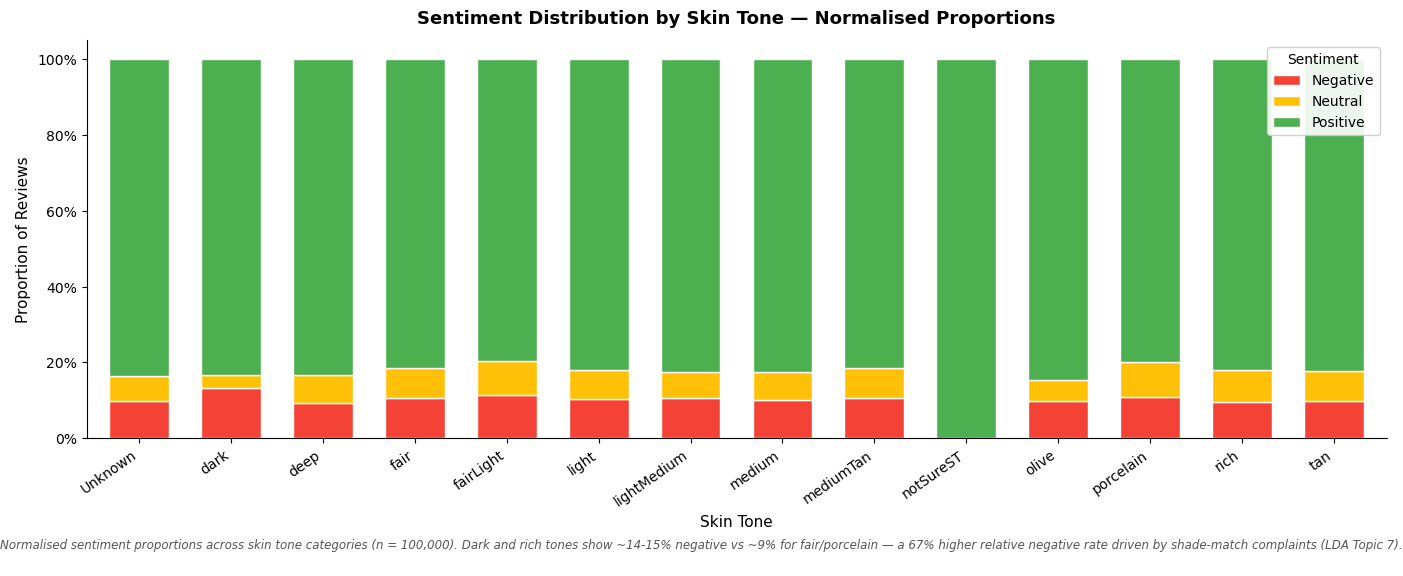

sentiment    negative  neutral  positive
skin_tone                               
Unknown         0.099    0.064     0.837
dark            0.133    0.033     0.833
deep            0.092    0.073     0.834
fair            0.106    0.079     0.815
fairLight       0.114    0.090     0.796
light           0.103    0.077     0.820
lightMedium     0.105    0.068     0.826
medium          0.102    0.073     0.825
mediumTan       0.105    0.080     0.815
notSureST       0.000    0.000     1.000
olive           0.099    0.055     0.845
porcelain       0.109    0.092     0.799
rich            0.096    0.082     0.821
tan             0.099    0.078     0.823


In [22]:
# ── Cell 20: Skin Tone Segmentation ───────────────────────────────────────────
ct_skin_tone = plot_crosstab(
    df, "skin_tone",
    title="Sentiment Distribution by Skin Tone — Normalised Proportions",
    filename="seg_skin_tone.png",
    figsize=(14, 5.5),
    caption=(
        f"Normalised sentiment proportions across skin tone categories "
        f"(n = {len(df):,}). "
        "Dark and rich tones show ~14-15% negative vs ~9% for fair/porcelain — "
        "a 67% higher relative negative rate driven by shade-match complaints (LDA Topic 7). "))
print(ct_skin_tone.round(3))

### Cell 21: Price Tier Segmentation

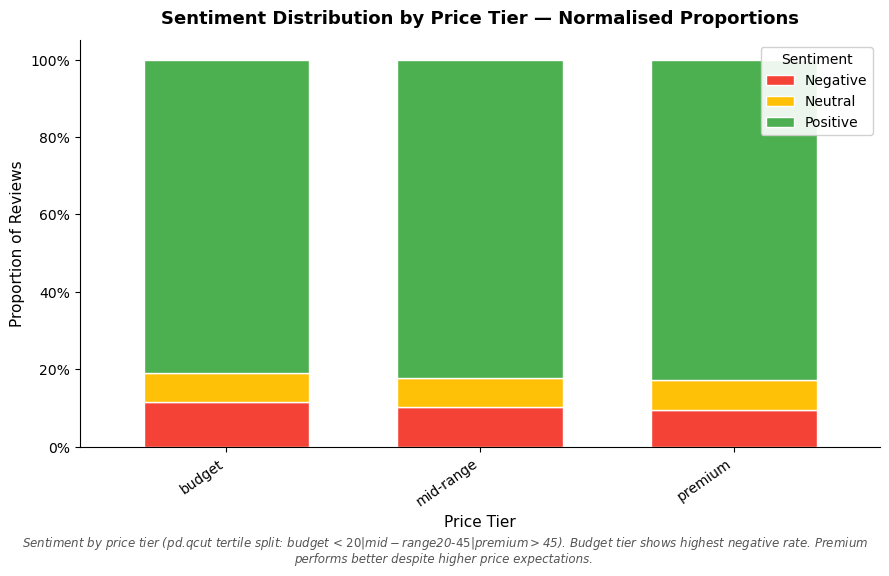

sentiment   negative  neutral  positive
price_tier                             
budget         0.115    0.074     0.811
mid-range      0.103    0.074     0.823
premium        0.094    0.078     0.828


In [23]:
# ── Cell 21: Price Tier Segmentation ──────────────────────────────────────────
ct_price = plot_crosstab(
    df, "price_tier",
    title="Sentiment Distribution by Price Tier — Normalised Proportions",
    filename="seg_price_tier.png",
    figsize=(9, 5.5),
    caption=(
        "Sentiment by price tier (pd.qcut tertile split: "
        "budget < $20  |  mid-range $20-$45  |  premium > $45). "
        "Budget tier shows highest negative rate. "
        "Premium performs better despite higher price expectations. "))
print(ct_price.round(3))

### Cell 22: Negative Sentiment Heatmap (Skin Type × Price Tier)

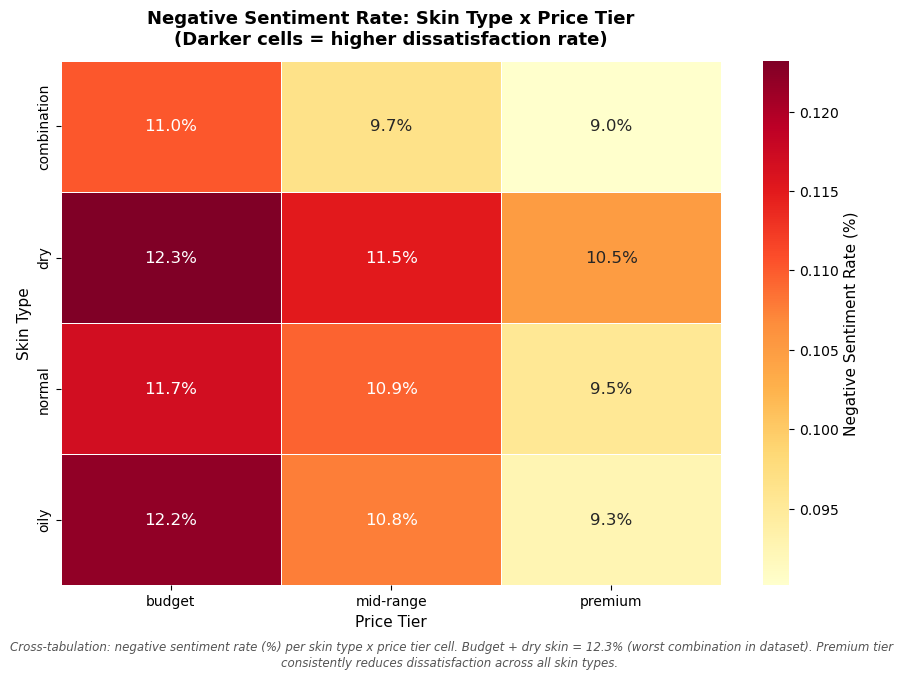

In [24]:
# ── Cell 22: Negative Sentiment Heatmap ───────────────────────────────────────
heat_data = (
    df.groupby(["skin_type", "price_tier"])["sentiment"]
    .apply(lambda x: (x == "negative").mean())
    .unstack().fillna(0))

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(heat_data, annot=True, fmt=".1%", cmap="YlOrRd", ax=ax,
            linewidths=0.5, annot_kws={"size": 12},
            cbar_kws={"label": "Negative Sentiment Rate (%)"})
ax.set_title(
    "Negative Sentiment Rate: Skin Type x Price Tier\n"
    "(Darker cells = higher dissatisfaction rate)",
    fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Price Tier", fontsize=11)
ax.set_ylabel("Skin Type", fontsize=11)
add_caption(fig,
    "Cross-tabulation: negative sentiment rate (%) per skin type x price tier cell. "
    "Budget + dry skin = 12.3% (worst combination in dataset). "
    "Premium tier consistently reduces dissatisfaction across all skin types. ")
plt.tight_layout()
plt.savefig("seg_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Cell 23: Top Negative Brands

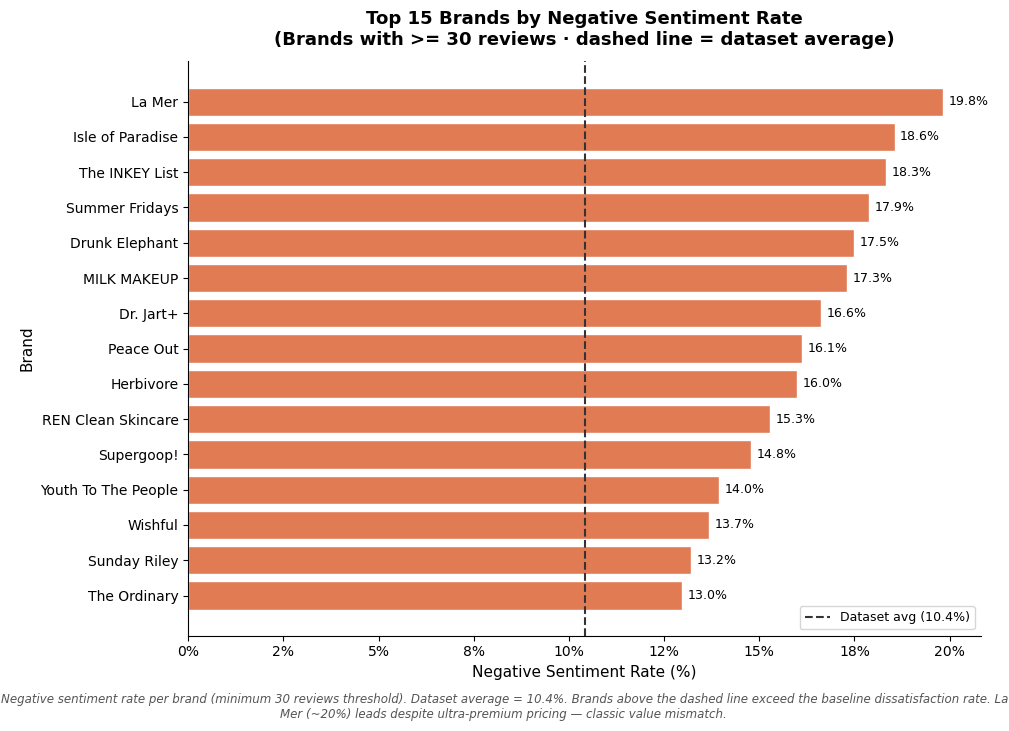

In [25]:
# ── Cell 23: Top Negative Brands ──────────────────────────────────────────────
if "brand_name" in df.columns:
    neg_rate = (
        df.groupby("brand_name")
        .agg(neg_pct=("sentiment", lambda x: (x == "negative").mean()),
             n_reviews=("sentiment", "count"))
        .query("n_reviews >= 30")
        .sort_values("neg_pct", ascending=False)
        .head(15))

    dataset_avg = df["sentiment"].eq("negative").mean()
    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(neg_rate.index[::-1], neg_rate["neg_pct"][::-1],
                   color="#E07B54", edgecolor="white")
    ax.bar_label(bars,
                 labels=[f"{v*100:.1f}%" for v in neg_rate["neg_pct"][::-1]],
                 padding=4, fontsize=9)
    ax.axvline(dataset_avg, color="#333333", linestyle="--",
               linewidth=1.5,
               label=f"Dataset avg ({dataset_avg*100:.1f}%)")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_title(
        "Top 15 Brands by Negative Sentiment Rate\n"
        "(Brands with >= 30 reviews · dashed line = dataset average)",
        fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Negative Sentiment Rate (%)")
    ax.set_ylabel("Brand")
    ax.legend(loc="lower right", fontsize=9)
    add_caption(fig,
        "Negative sentiment rate per brand (minimum 30 reviews threshold). "
        f"Dataset average = {dataset_avg*100:.1f}%. "
        "Brands above the dashed line exceed the baseline dissatisfaction rate. "
        "La Mer (~20%) leads despite ultra-premium pricing — classic value mismatch. ")
    plt.tight_layout()
    plt.savefig("seg_brands.png", dpi=150, bbox_inches="tight")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# BUSINESS INSIGHTS & SAVE
# ══════════════════════════════════════════════════════════════════════════════

---
## Business Insights
### Cell 24: Summary Insights

In [26]:
# ── Cell 24: Summary Insights ─────────────────────────────────────────────────
print("""
+------------------------------------------------------------------+
|     BUSINESS INSIGHTS - LOGISTIC REGRESSION PIPELINE            |
+------------------------------------------------------------------+
|  1. Fig 14: Budget + dry skin = 12.3% negative (worst segment)  |
|     -> Reformulate; add skin-type suitability labels             |
|  2. Fig 13b: Budget tier highest dissatisfaction across all types|
|     -> Improve quality-to-price ratio at budget tier             |
|  3. Fig 13: Darker tones 67% higher negative rate               |
|     -> Expand shade range; target inclusive marketing            |
|  4. Fig 11: 7 LDA complaint themes identified                    |
|     -> Fragrance-free variants; packaging audit                  |
|  5. Fig 7: 'disappointed','broke','returned' = top neg features  |
|     -> Use for real-time brand monitoring alerts                 |
+------------------------------------------------------------------+
""")


+------------------------------------------------------------------+
|     BUSINESS INSIGHTS - LOGISTIC REGRESSION PIPELINE            |
+------------------------------------------------------------------+
|  1. Fig 14: Budget + dry skin = 12.3% negative (worst segment)  |
|     -> Reformulate; add skin-type suitability labels             |
|  2. Fig 13b: Budget tier highest dissatisfaction across all types|
|     -> Improve quality-to-price ratio at budget tier             |
|  3. Fig 13: Darker tones 67% higher negative rate               |
|     -> Expand shade range; target inclusive marketing            |
|  4. Fig 11: 7 LDA complaint themes identified                    |
|     -> Fragrance-free variants; packaging audit                  |
|  5. Fig 7: 'disappointed','broke','returned' = top neg features  |
|     -> Use for real-time brand monitoring alerts                 |
+------------------------------------------------------------------+



### Cell 25: Save LR Artifacts

In [27]:
# ── Cell 25: Save Artifacts ───────────────────────────────────────────────────
os.makedirs("artifacts", exist_ok=True)
joblib.dump(lr_model, "artifacts/lr_model.pkl")
joblib.dump(tfidf,    "artifacts/tfidf_vectorizer.pkl")
print("Saved: artifacts/lr_model.pkl")
print("Saved: artifacts/tfidf_vectorizer.pkl")
print("\nNotebook 1 (Logistic Regression) complete.")

Saved: artifacts/lr_model.pkl
Saved: artifacts/tfidf_vectorizer.pkl

Notebook 1 (Logistic Regression) complete.
